In [3]:
import pandas as pd
from dotenv import load_dotenv
import psycopg2
import os

In [4]:
load_dotenv()
url = os.getenv("DATABASE_URL")

In [75]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

query = """
SELECT timestamp, ticker, side, volume, price FROM orders
ORDER BY volume DESC
"""
cur.execute(query)
rows = cur.fetchall()

In [76]:
df = pd.DataFrame(rows, columns=['timestamp', 'ticker', 'side', 'volume', 'price'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

,ticker,side,volume,price
timestamp,,,,
2026-04-29 16:47:14+00:00,SR320CF6,SELL,270000,12
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-26 15:18:50+00:00,SR320CP6A,SELL,74862,4
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9


In [77]:
df.describe()

,volume,price
count,9912.000000,9912.000000
mean,1582.101493,5.803370
std,5143.079989,7.397118
min,0.000000,0.000000
25%,22.000000,0.000000
50%,116.000000,3.000000
75%,816.000000,9.000000
max,270000.000000,55.000000


In [78]:
buy_df = df[df['side'] == "BUY"]
buy_df.head()

,ticker,side,volume,price
timestamp,,,,
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9
2026-04-24 19:06:47+00:00,SR320CE6A,BUY,48182,8
2026-04-17 13:44:19+00:00,SR310CF6,BUY,47000,23


In [91]:
top_10_buy_df = buy_df.head(10)
top_10_buy_df

,ticker,side,volume,price
timestamp,,,,
2026-04-01 10:56:46+00:00,SR310CD6B,BUY,153143,8
2026-03-25 11:46:13+00:00,SR310CD6,BUY,63350,12
2026-03-25 06:19:33+00:00,SR310CC6D,BUY,51150,9
2026-04-24 19:06:47+00:00,SR320CE6A,BUY,48182,8
2026-04-17 13:44:19+00:00,SR310CF6,BUY,47000,23
2026-04-23 12:26:07+00:00,SR320CE6A,BUY,43566,10
2026-04-22 13:37:36+00:00,SR310CD6E,BUY,37584,15
2026-03-27 11:12:23+00:00,SR310CD6,BUY,37505,9
2026-04-17 06:56:10+00:00,SR320CD6E,BUY,36740,6


In [92]:
query = """
SELECT timestamp, ticker, bids, asks FROM orderbooks
WHERE ticker = ANY(%s)
"""
tickers = top_10_buy_df['ticker'].unique().tolist()
cur.execute(query, (tickers,))
rows = cur.fetchall()

OperationalError: SSL SYSCALL error: EOF detected


In [93]:
orderbooks_df = pd.DataFrame(rows, columns=['timestamp', 'ticker', 'bids', 'asks'])
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.head()

,ticker,bids,asks
timestamp,,,
2026-04-20 11:35:38+00:00,SR300CE6,"[{'price': 27.45, 'quantity': 800}, {'price': ...","[{'price': 28.56, 'quantity': 200}, {'price': ..."
2026-04-20 11:35:39+00:00,SR320CE6,"[{'price': 10.8, 'quantity': 800}, {'price': 1...","[{'price': 11.65, 'quantity': 5500}, {'price':..."
2026-04-20 11:35:39+00:00,SR330CE6,"[{'price': 5.14, 'quantity': 2000}, {'price': ...","[{'price': 5.92, 'quantity': 5500}, {'price': ..."
2026-04-20 11:35:40+00:00,SR350CQ6,"[{'price': 21.76, 'quantity': 800}, {'price': ...","[{'price': 23.1, 'quantity': 5500}, {'price': ..."
2026-04-20 11:35:40+00:00,SR360CQ6,"[{'price': 31.27, 'quantity': 800}, {'price': ...","[{'price': 32.07, 'quantity': 800}, {'price': ..."


In [94]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
orderbooks_df['mid_price'] = orderbooks_df['best_bid'] + (orderbooks_df['best_ask'] - orderbooks_df['best_bid'])/2
prices_df = orderbooks_df[['ticker', 'mid_price']]
prices_df.head()

,ticker,mid_price
timestamp,,
2026-04-20 11:35:38+00:00,SR300CE6,28.005
2026-04-20 11:35:39+00:00,SR320CE6,11.225
2026-04-20 11:35:39+00:00,SR330CE6,5.530
2026-04-20 11:35:40+00:00,SR350CQ6,22.430
2026-04-20 11:35:40+00:00,SR360CQ6,31.670


In [95]:
top_10_buy_df = top_10_buy_df.sort_index()
prices_df = prices_df.sort_values(['ticker', 'timestamp'])

In [96]:
base = pd.merge_asof(
    top_10_buy_df.sort_index(),
    prices_df.sort_values('timestamp'),
    left_on='timestamp',
    right_on='timestamp',
    by='ticker',
    direction='backward'
).rename(columns={'mid_price': 'mid_0'})

In [97]:
horizons = ['5min', '15min', '45min','1h', '4h', '8h', '12h', '1D', ]

base = base.reset_index(drop=True)

prices_sorted = prices_df.sort_values('timestamp')

for h in horizons:
    tmp = base.copy()

    tmp['target_time'] = tmp['timestamp'] + pd.Timedelta(h)

    tmp = tmp.sort_values('target_time')

    tmp = pd.merge_asof(
        tmp,
        prices_sorted,
        left_on='target_time',
        right_on='timestamp',
        by='ticker',
        direction='forward'
    )

    base[f'mid_{h}'] = tmp['mid_price'].values

In [98]:
for h in horizons:
    base[f'return_{h}'] = (base[f'mid_{h}'] - base['price']) / base['price']
base.head()

,ticker,timestamp,side,volume,price,mid_0,mid_5min,mid_15min,mid_45min,mid_1h,...,mid_12h,mid_1D,return_5min,return_15min,return_45min,return_1h,return_4h,return_8h,return_12h,return_1D
0,SR310CC6D,2026-03-25 06:19:33+00:00,BUY,51150,9,8.810,8.805,8.590,8.465,7.945,...,NaN,NaN,-0.021667,-0.045556,-0.059444,-0.117222,-0.178889,-0.173333,NaN,NaN
1,SR310CD6,2026-03-25 11:46:13+00:00,BUY,63350,12,12.335,12.280,12.235,12.065,12.140,...,NaN,10.980,0.023333,0.019583,0.005417,0.011667,0.002083,-0.008750,NaN,-0.085000
2,SR310CD6,2026-03-27 11:12:23+00:00,BUY,37505,9,9.630,9.850,9.850,9.940,9.855,...,9.56,9.560,0.094444,0.094444,0.104444,0.095000,-0.073333,-0.040000,0.062222,0.062222
3,SR310CD6B,2026-04-01 10:56:46+00:00,BUY,153143,8,8.345,8.240,8.240,7.665,7.580,...,NaN,7.435,0.030000,0.030000,-0.041875,-0.052500,-0.015625,-0.003750,NaN,-0.070625
4,SR320CD6E,2026-04-17 06:56:10+00:00,BUY,36740,6,6.685,5.765,5.770,6.175,7.040,...,7.18,7.720,-0.039167,-0.038333,0.029167,0.173333,0.060833,0.063333,0.196667,0.286667


In [99]:
base[[f'return_{h}' for h in horizons]].describe()

,return_5min,return_15min,return_45min,return_1h,return_4h,return_8h,return_12h,return_1D
count,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000,4.000000,7.000000
mean,0.023038,0.021132,0.020149,0.028074,0.001477,-0.035143,0.053347,0.024395
std,0.044860,0.045837,0.048847,0.079904,0.092041,0.073573,0.111282,0.176210
min,-0.039167,-0.045556,-0.059444,-0.117222,-0.178889,-0.173333,-0.072500,-0.182000
25%,-0.010417,-0.012354,0.005813,0.008167,-0.058281,-0.056250,0.002125,-0.078750
50%,0.028261,0.024130,0.015435,0.016522,0.018216,-0.011000,0.044611,-0.070625
75%,0.053437,0.053437,0.053229,0.073438,0.054212,-0.006250,0.095833,0.147111
max,0.094444,0.094444,0.104444,0.173333,0.146000,0.063333,0.196667,0.286667


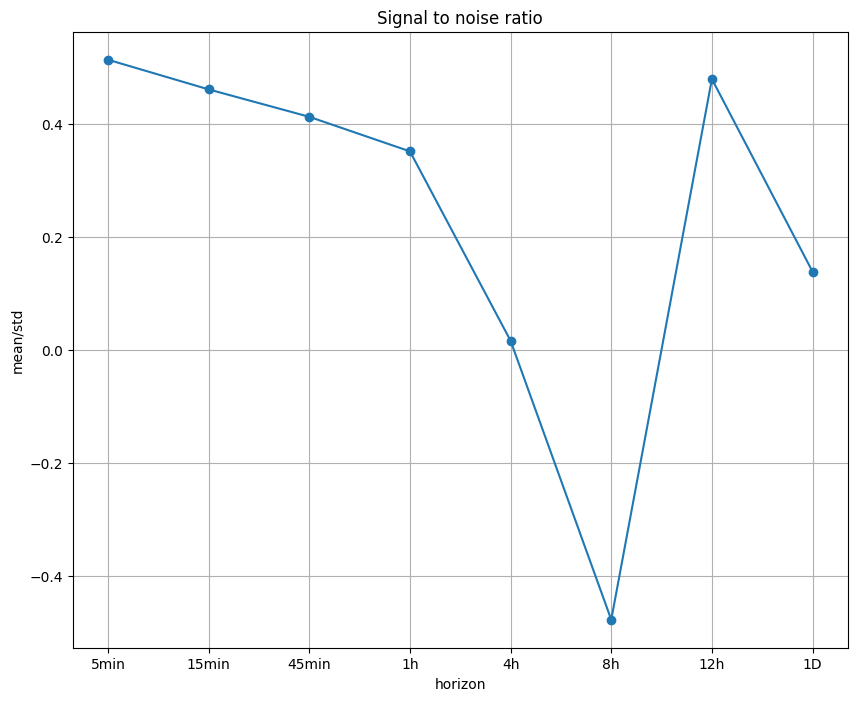

In [110]:
snr = []

for h in horizons:
    col = f'return_{h}'
    s = base[col].dropna()
    snr.append(s.mean() / s.std())

fig = plt.figure(figsize=(10,8))
plt.plot(horizons, snr, marker='o')
plt.title("Signal to noise ratio")
plt.xlabel("horizon")
plt.ylabel("mean/std")
plt.grid()
plt.show()